## Exercise: Advanced dimensionality reduction techniques

#### In this notebook, we'll investigate how PCA, MDS, and t-SNE dimensionality reduction techniques work on image and text data.

### Learning Objectives
#### By the end of this notebook, you should be able to:
#### - Understand advanced dimensionality reduction techniques
#### - Implement these techniques on image and text data

### Exercises

#### Exercise 1: Principal Component Analysis (PCA)
#### 1. Apply PCA to the wine dataset and reduce the dimensionality to 2 components. How much variance is explained by the first two principal components?
#### 2. After applying PCA, plot the transformed data points on a scatter plot with different colors for each class. Are the classes well-separated in the reduced dimensionality space?

In [2]:
from sklearn.datasets import load_wine

wine = load_wine()

In [30]:
import pandas as pd

X = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

y = wine.target

In [31]:
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [9]:
X_scaled.shape

(178, 13)

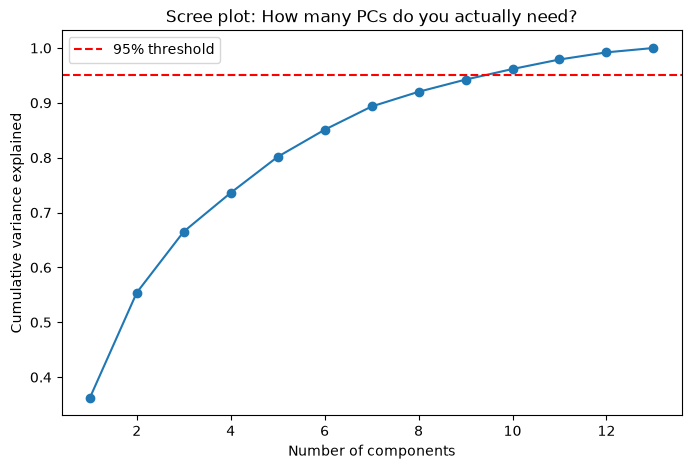

In [28]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca_full = PCA().fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.xlabel('Number of components')
plt.ylabel('Cumulative variance explained')
plt.title('Scree plot: How many PCs do you actually need?')
plt.legend()
plt.show()

In [14]:
pca_full.n_components_

13

Keeping 2 components retains 55.41% of the variance


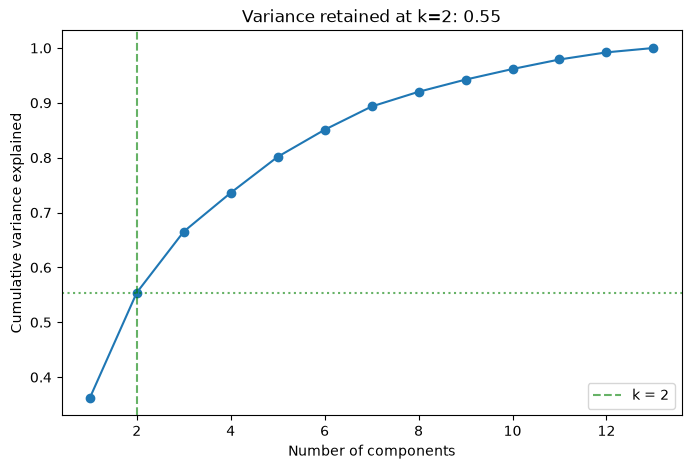

In [26]:
k = 2 # number of components

variance_retained = pca_full.explained_variance_ratio_[:k].sum()
print(f'Keeping {k} components retains {variance_retained:.2%} of the variance')

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axvline(x=k, color='g', linestyle='--', label=f'k = {k}', alpha=0.6)
plt.axhline(y=cumulative_variance[k-1], color='g', linestyle=':', alpha=0.6)
plt.xlabel('Number of components')
plt.ylabel('Cumulative variance explained')
plt.title(f'Variance retained at k={k}: {cumulative_variance[k-1]:.2f}')
plt.legend()
plt.show()

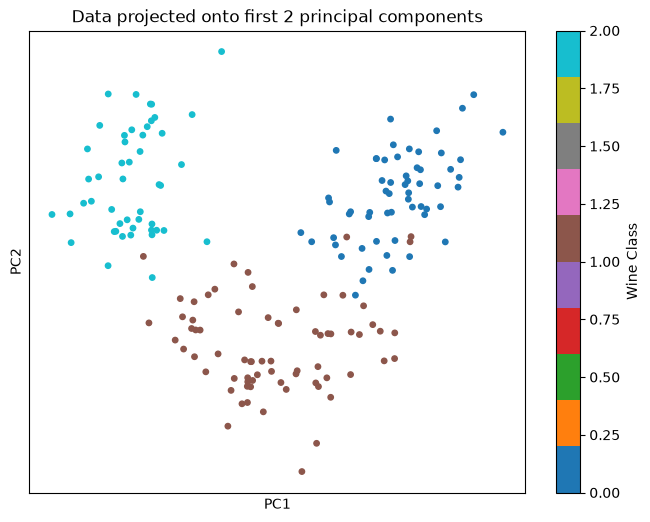

In [61]:
X_transformed = pca_full.transform(X_scaled)[:, :k]

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_transformed[:, 0],
    X_transformed[:, 1],
    c=y,
    cmap='tab10',
    s=15
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.xticks([])
plt.yticks([])
plt.title(f'Data projected onto first {k} principal components')
plt.colorbar(scatter, label='Wine Class')
plt.show()

### Exercise 2: Multi-dimensional Scaling (MDS)

#### 1. Apply MDS to the wine dataset and reduce the dimensionality to 2 components. What is the stress value of the MDS transformation?
#### 2. Plot the transformed data points on a scatter plot with different colors for each class. Do you observe any clusters or patterns in the reduced dimensionality space?

In [40]:
from sklearn.manifold import MDS

mds = MDS(
    n_components=2,
    dissimilarity='euclidean',
    random_state=42,
    normalized_stress='auto'
)

X_mds = mds.fit_transform(X_scaled)

print(f'MDS stress values: {mds.stress_}')

D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\manifold\_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


MDS stress values: 21607.89505024592


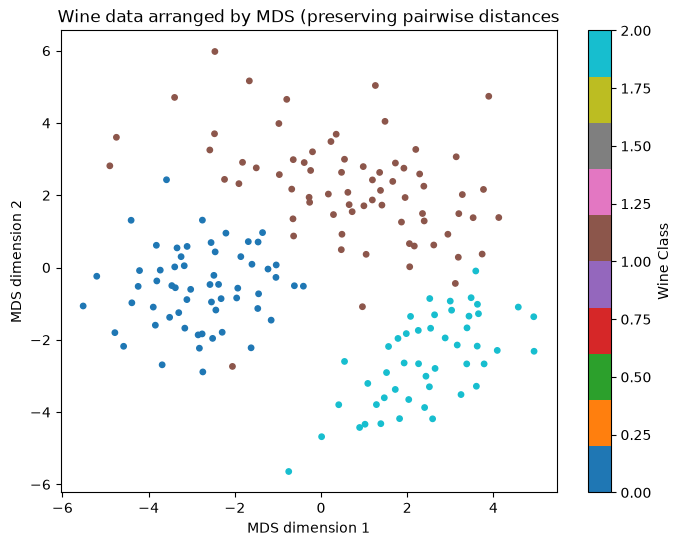

In [60]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_mds[:, 0],
    X_mds[:, 1],
    c=y,
    cmap='tab10',
    s=15
)
plt.xlabel('MDS dimension 1')
plt.ylabel('MDS dimension 2')
plt.title('Wine data arranged by MDS (preserving pairwise distances')
plt.colorbar(scatter, label='Wine Class')
plt.show()

### MDS with subsampling

In [44]:
rng = np.random.RandomState(42)
subset_idx = rng.choice(len(X_scaled), size=89, replace=False)

X_subset = X_scaled[subset_idx]
y_subset = y[subset_idx]

mds_subsample = MDS(
    n_components=2,
    dissimilarity='euclidean',
    random_state=42,
    normalized_stress='auto'
)

X_mds_subsample = mds_subsample.fit_transform(X_subset)
print(f'Stress: {mds_subsample.stress_}')

D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\manifold\_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


Stress: 5304.227770937947


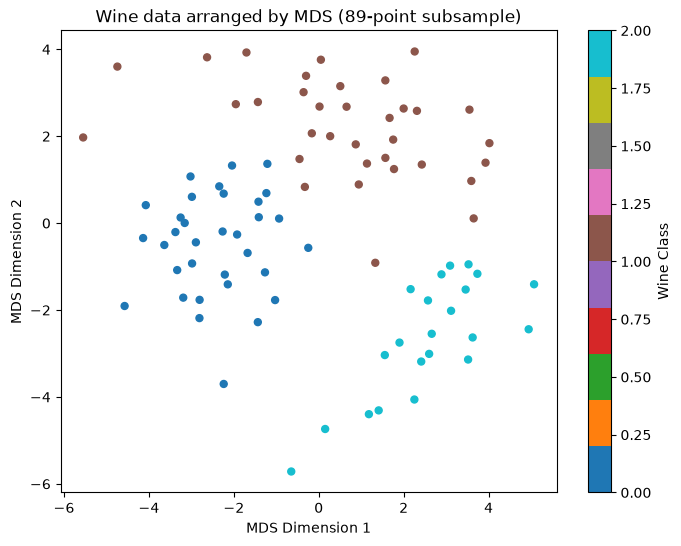

In [59]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_mds_subsample[:, 0],
    X_mds_subsample[:, 1],
    c=y_subset,
    cmap='tab10',
    s=25
)

plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.title('Wine data arranged by MDS (89-point subsample)')
plt.colorbar(scatter, label='Wine Class')
plt.show()

### Visualizing dimensions against stress level in MDS

D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\manifold\_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\manifold\_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
D:\Users\s

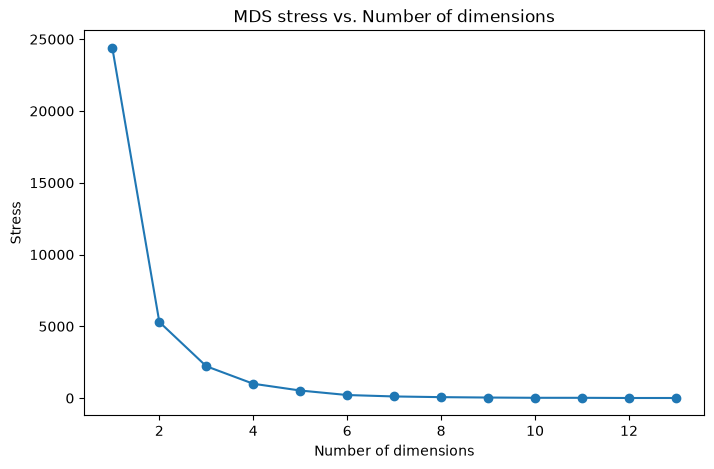

In [56]:
# try a range of dimensionalities
component_range = range(1, 14)
stress_values = []

for n in component_range:
    mds_plot = MDS(
        n_components=n,
        dissimilarity='euclidean',
        random_state=42,
        normalized_stress='auto'
    )

    mds_plot.fit(X_subset)
    stress_values.append(mds_plot.stress_)

plt.figure(figsize=(8,5))
plt.plot(component_range, stress_values, marker='o')
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Number of dimensions')
plt.ylabel('Stress')
plt.title('MDS stress vs. Number of dimensions')
plt.show()

### Exercise 3: t-distributed Stochastic Neighbour Embedding (t-SNE)

#### 1. Apply t-SNE to the wine dataset and reduce the dimensionaloty to 2 components. How long does it take to compute the t-SNE embedding?
#### 2. Plot the transformed data points on a scatter plot with different colors for each class. What do you observe about the clusters in the reduced dimensionality space?

In [50]:
import time
from sklearn.manifold import TSNE

X_scaled = StandardScaler().fit_transform(X)

start_time = time.perf_counter()

tsne = TSNE(
    n_components=2,
    perplexity=50,
    random_state=42,
    init='pca'
)

X_tsne = tsne.fit_transform(X_scaled)

end_time = time.perf_counter()

print(f'KL Divergence Score: {tsne.kl_divergence_}')
print(f't-SNE took {end_time - start_time:.2f} seconds')

KL Divergence Score: 0.24403756856918335
t-SNE took 6.79 seconds


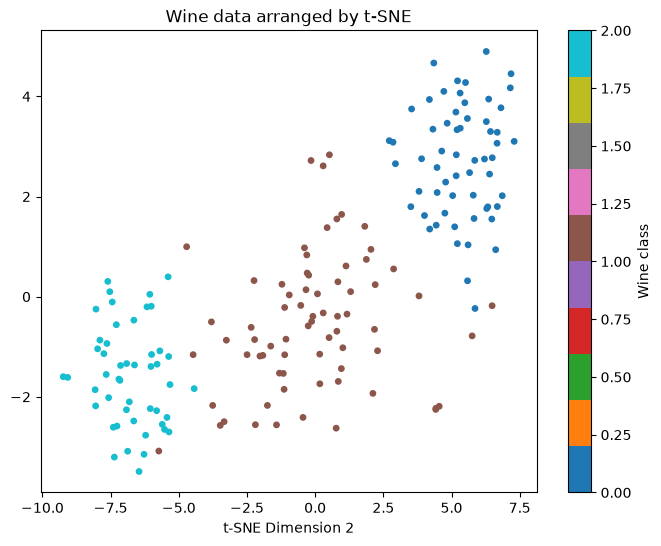

In [58]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap='tab10',
    s=15
)

plt.xlabel('t-SNE Dimension 1')
plt.xlabel('t-SNE Dimension 2')
plt.title('Wine data arranged by t-SNE')
plt.colorbar(scatter, label='Wine class')
plt.show()

## Examiner Answers

Explained variance ratio by the first two principal components:  [0.99809123 0.00173592]


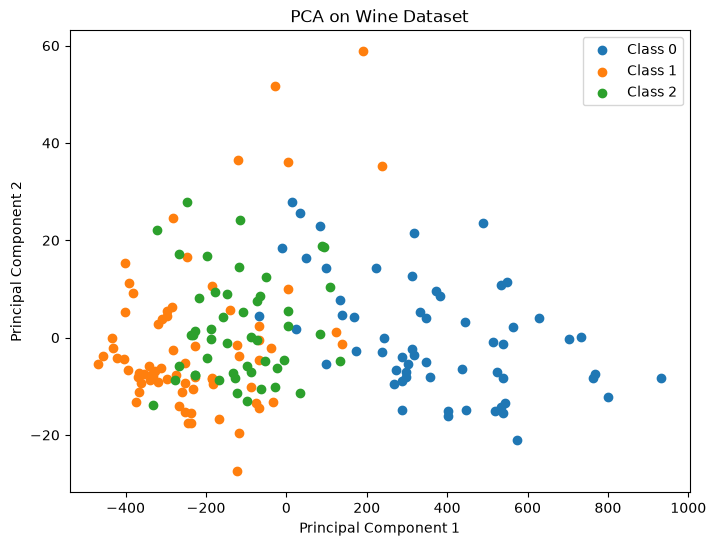

In [62]:
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load the wine dataset
data = load_wine()
X = data.data
y = data.target

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Display the explained variance ratio
print("Explained variance ratio by the first two principal components: ", pca.explained_variance_ratio_)

# Plot the transformed data points
plt.figure(figsize=(8, 6))
for i in range(len(set(y))):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=f'Class {i}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA on Wine Dataset')
plt.legend()
plt.show()

D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


Stress value of the MDS transformation:  90909.14160933718


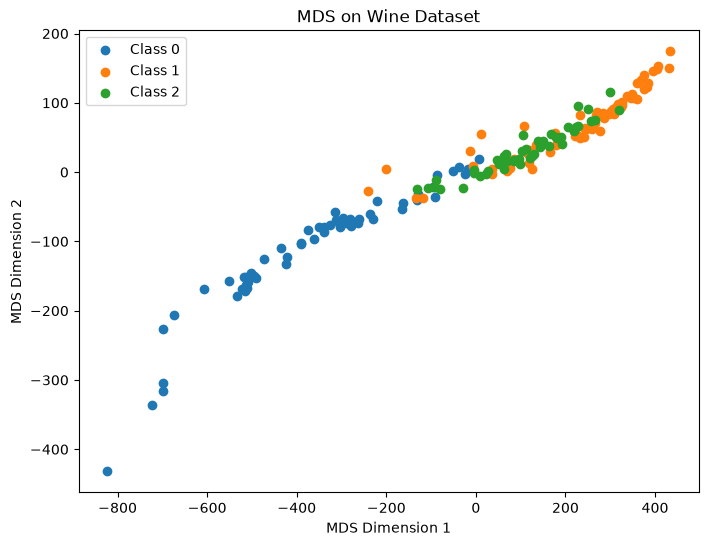

In [63]:
from sklearn.datasets import load_wine
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

# Load the wine dataset
data = load_wine()
X = data.data
y = data.target

# Perform MDS
mds = MDS(n_components=2, random_state=42)
X_mds = mds.fit_transform(X)

# Display the stress value
print("Stress value of the MDS transformation: ", mds.stress_)

# Plot the transformed data points
plt.figure(figsize=(8, 6))
for i in range(len(set(y))):
    plt.scatter(X_mds[y == i, 0], X_mds[y == i, 1], label=f'Class {i}')
plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.title('MDS on Wine Dataset')
plt.legend()
plt.show()

Time taken to compute t-SNE embedding:  1.5726051330566406  seconds


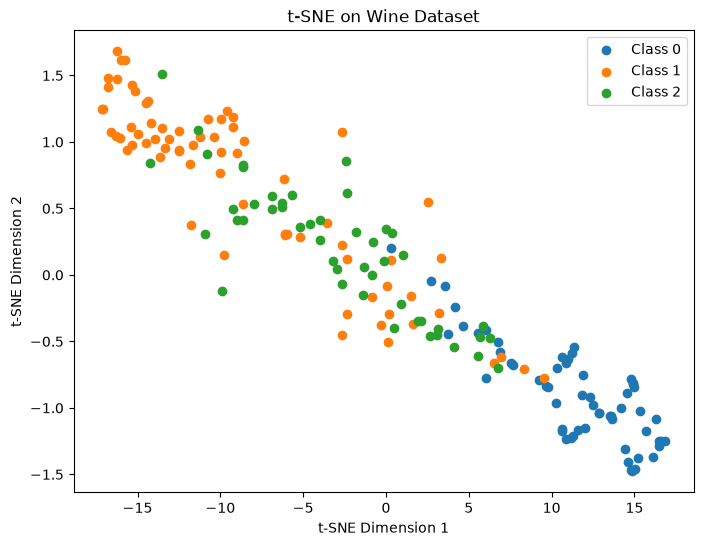

In [64]:
from sklearn.datasets import load_wine
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import time

# Load the wine dataset
data = load_wine()
X = data.data
y = data.target

# Perform t-SNE
tsne = TSNE(n_components=2, random_state=42)
start_time = time.time()
X_tsne = tsne.fit_transform(X)
end_time = time.time()

# Display the time taken
print("Time taken to compute t-SNE embedding: ", end_time - start_time, " seconds")

# Plot the transformed data points
plt.figure(figsize=(8, 6))
for i in range(len(set(y))):
    plt.scatter(X_tsne[y == i, 0], X_tsne[y == i, 1], label=f'Class {i}')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE on Wine Dataset')
plt.legend()
plt.show()